# S2 — CMIP6 land-dataset preparation / CMIP6陆地数据集构建

This notebook converts the global S1 products into analysis-ready land datasets. Ocean cells are excluded, while all land cells are retained. Non-ice land, land with prescribed ice, and land whose ice status is unknown remain explicit labels rather than irreversible filters. No variable pairing, relationship fitting, or classification is performed here.

**中文说明：** 本Notebook把S1生成的全球年度与气候态产品转换成可供后续分析使用的陆地数据集。这里只删除海洋，保留全部陆地格点；非冰陆地、存在陆地冰的格点以及冰况未知的陆地格点均作为明确标签保存，而不是提前删除。S2同时保留格点总面积、陆地面积、陆地冰面积和非冰陆地面积，供后续根据分析域选择权重。本步骤不生成变量对子，不运行MIC、power-law或classifier。

## 1. Configuration / 配置

Select S1 runs by model, experiment, and period. The implementation supports multiple matching members and grids, although the first execution uses one model for end-to-end validation. A positive land fraction defines a terrestrial cell. A positive land-ice fraction labels a land cell as containing prescribed land ice.

**中文说明：** 本步骤配置需要处理的模型、experiment和历史时期。程序会在`caseA/data/{model}/{experiment}/{member}/{grid}/processed`中自动寻找S1年度产品，因此member和grid沿用S1实际解析结果，不重新硬编码。`sftlf>0`定义陆地格点；若`sftgif`可用，则`sftgif>0`表示该陆地格点存在规定的陆地冰。阈值显式写入配置和输出元数据，后续如需敏感性分析可以调整。

In [18]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display
from matplotlib.colors import BoundaryNorm, ListedColormap


def locate_case_dir() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for candidate in candidates:
        if (candidate / 'cmip_utils.py').exists() and candidate.name == 'caseA':
            return candidate
        nested = candidate / 'case' / 'caseA'
        if (nested / 'cmip_utils.py').exists():
            return nested
    raise FileNotFoundError('Could not locate case/caseA/cmip_utils.py')


CASE_DIR = locate_case_dir()
DATA_ROOT = Path('/Volumes/mimi-T9/CMIP6')
if str(CASE_DIR) not in sys.path:
    sys.path.insert(0, str(CASE_DIR))

from cmip_utils import processing_signature

MODELS = [
    'CESM2', 'CNRM-CM6-1', 'CanESM5', 'E3SM-1-0', 'GFDL-CM4',
    'IPSL-CM6A-LR', 'MIROC-ES2H', 'MRI-ESM2-0',
    'CMCC-CM2-SR5', 'FGOALS-g3', 'NorESM2-LM',
]
EXPERIMENTS = ['historical']
START_YEAR = 1985
END_YEAR = 2014
LAND_FRACTION_THRESHOLD = 0.0
LAND_ICE_FRACTION_THRESHOLD = 0.0
RATIO_MIN_P_MM_YR = 1.0
REUSE_VALID_OUTPUTS = True
PROCESSING_VERSION = 'S2-land-v2'

print('Case directory:', CASE_DIR)
print('Data root:', DATA_ROOT)
print('Models:', MODELS)
print('Experiments:', EXPERIMENTS)
print('Period:', f'{START_YEAR}-{END_YEAR}')

Case directory: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA
Data root: /Volumes/mimi-T9/CMIP6
Models: ['CESM2', 'CNRM-CM6-1', 'CanESM5', 'E3SM-1-0', 'GFDL-CM4', 'IPSL-CM6A-LR', 'MIROC-ES2H', 'MRI-ESM2-0', 'CMCC-CM2-SR5', 'FGOALS-g3', 'NorESM2-LM']
Experiments: ['historical']
Period: 1985-2014


## 2. Discover and validate S1 inputs / 发现并验证S1输入

Each matching S1 annual NetCDF is treated as one independent run. The companion global climatology must exist. Source identity is read from the dataset attributes and checked against the directory selected by the configuration.

**中文说明：** 程序为每个模型和experiment寻找名称与请求时期完全匹配的`global_annual`和`global_climatology`文件。每个member与grid组合视为独立run，不把不同member或不同网格混在一起。这里仅发现本地S1产品，不访问ESGF，也不重新下载。输入清单会显示模型、experiment、member、grid、文件路径和文件大小，缺少配套气候态文件时立即报错。

In [19]:
RUNS = []
SKIPPED_MODELS = []
for model in MODELS:
    for experiment in EXPERIMENTS:
        search_root = DATA_ROOT / model / experiment
        annual_name = f'global_annual_{START_YEAR}_{END_YEAR}.nc'
        annual_paths = sorted(search_root.glob(f'*/*/processed/{annual_name}'))
        if not annual_paths:
            print(f'{model}: no S1.1 output found, skipping')
            SKIPPED_MODELS.append(model)
            continue
        for annual_path in annual_paths:
            processed_dir = annual_path.parent
            run_root = processed_dir.parent
            climatology_path = processed_dir / f'global_climatology_{START_YEAR}_{END_YEAR}.nc'
            if not climatology_path.exists():
                print(f'{model}: missing climatology at {climatology_path}, skipping')
                SKIPPED_MODELS.append(model)
                continue
            with xr.open_dataset(annual_path) as source:
                attrs = dict(source.attrs)
                sizes = dict(source.sizes)
            if attrs.get('source_id') != model or attrs.get('experiment_id') != experiment:
                raise ValueError(f'S1 identity mismatch in {annual_path}')
            RUNS.append({
                'model': model,
                'experiment': experiment,
                'member': attrs.get('member_id', run_root.parent.name),
                'grid': attrs.get('grid_label', run_root.name),
                'run_root': run_root,
                'annual_path': annual_path,
                'global_climatology_path': climatology_path,
                'sizes': sizes,
                's1_processing_version': attrs.get('processing_version'),
                'land_ice_status': attrs.get('land_ice_status', 'unknown'),
            })

INPUT_INVENTORY = pd.DataFrame([{
    'model': run['model'],
    'experiment': run['experiment'],
    'member': run['member'],
    'grid': run['grid'],
    'years': run['sizes'].get('year'),
    'lat': run['sizes'].get('lat'),
    'lon': run['sizes'].get('lon'),
    'land_ice_status': run['land_ice_status'],
    'annual_file_MB': run['annual_path'].stat().st_size / 1e6,
    'annual_path': str(run['annual_path']),
} for run in RUNS])
print(f'\nFound {len(RUNS)} runs, skipped {len(SKIPPED_MODELS)} models: {SKIPPED_MODELS}')
display(INPUT_INVENTORY)

MIROC-ES2H: no S1.1 output found, skipping
MRI-ESM2-0: no S1.1 output found, skipping

Found 9 runs, skipped 2 models: ['MIROC-ES2H', 'MRI-ESM2-0']


,model,experiment,member,grid,years,lat,lon,land_ice_status,annual_file_MB,annual_path
0,CESM2,historical,r1i1p1f1,gn,30,192,288,available,241.648180,/Volumes/mimi-T9/CMIP6/CESM2/historical/r1i1p1...
1,CNRM-CM6-1,historical,r1i1p1f2,gr,30,128,256,available,143.231372,/Volumes/mimi-T9/CMIP6/CNRM-CM6-1/historical/r...
2,CanESM5,historical,r1i1p1f1,gn,30,64,128,available,35.889272,/Volumes/mimi-T9/CMIP6/CanESM5/historical/r1i1...
3,E3SM-1-0,historical,r1i1p1f1,gr,30,180,360,unavailable,283.136138,/Volumes/mimi-T9/CMIP6/E3SM-1-0/historical/r1i...
4,GFDL-CM4,historical,r1i1p1f1,gr1,30,180,288,available,226.523548,/Volumes/mimi-T9/CMIP6/GFDL-CM4/historical/r1i...
5,IPSL-CM6A-LR,historical,r1i1p1f1,gr,30,143,144,unavailable,90.049358,/Volumes/mimi-T9/CMIP6/IPSL-CM6A-LR/historical...
6,CMCC-CM2-SR5,historical,r1i1p1f1,gn,30,192,288,available,241.619378,/Volumes/mimi-T9/CMIP6/CMCC-CM2-SR5/historical...
7,FGOALS-g3,historical,r1i1p1f1,gn,30,80,180,unavailable,63.001373,/Volumes/mimi-T9/CMIP6/FGOALS-g3/historical/r1...
8,NorESM2-LM,historical,r1i1p1f1,gn,30,96,144,available,47.192265,/Volumes/mimi-T9/CMIP6/NorESM2-LM/historical/r...


## 3. Build land datasets and labels / 构建陆地数据集与标签

The regular latitude–longitude topology is retained in NetCDF: ocean values of P, ET, R, WB, and diagnostic ratios become missing, while masks and fixed fields remain available for auditing. Parquet products physically retain land rows only. `surface_class_code` uses 0=ocean, 1=non-ice land, 2=land with prescribed ice, and 3=land whose ice status is unknown.

**中文说明：** 本步骤只用`sftlf`判断并删除海洋，不根据R是否缺失推断海洋。NetCDF继续保持规则经纬度网格，便于空间绘图，但P、ET、R、WB和比例变量在海洋上设为缺失；Parquet则真正只保留陆地行。若`sftgif`可用，陆地格点被标为`non_ice_land`或`land_ice`；若不可用，全部陆地标为`land_ice_unknown`，不会误标成非冰陆地。程序还生成跨年度稳定的`grid_id`，并明确保存`cell_area`、`land_area`、`land_ice_area`和`non_ice_land_area`，此时不创建含义模糊的统一`area_weight`。

In [20]:
REQUIRED_VARIABLES = {
    'P', 'ET', 'R', 'WB', 'cell_area', 'land_fraction',
    'land_ice_fraction', 'land_area', 'land_ice_area', 'non_ice_land_area',
}
PRIMARY_VARIABLES = ['P', 'ET', 'R', 'WB']
FIXED_FIELD_NAMES = {
    'cell_area', 'land_fraction', 'land_ice_fraction',
    'land_area', 'land_ice_area', 'non_ice_land_area',
}
FIXED_VARIABLES = [
    'grid_id_numeric', 'land_cell', 'surface_class_code', 'has_land_ice',
    'cell_area', 'land_fraction', 'land_ice_fraction', 'land_area',
    'land_ice_area', 'non_ice_land_area',
]
SURFACE_CLASS = {0: 'ocean', 1: 'non_ice_land', 2: 'land_ice', 3: 'land_ice_unknown'}


def _slug(value: str) -> str:
    return ''.join(character if character.isalnum() else '_' for character in str(value)).strip('_')


def _atomic_netcdf(dataset: xr.Dataset, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + '.tmp')
    dataset.to_netcdf(temporary)
    temporary.replace(path)


def _atomic_parquet(frame: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + '.tmp')
    frame.to_parquet(temporary, index=False, compression='zstd')
    temporary.replace(path)


def _add_table_metadata(frame: pd.DataFrame, run: dict) -> pd.DataFrame:
    frame = frame.copy()
    frame['surface_class'] = frame['surface_class_code'].map(SURFACE_CLASS)
    prefix = '_'.join(_slug(run[key]) for key in ('model', 'member', 'grid'))
    frame['grid_id'] = frame['grid_id_numeric'].map(
        lambda value: f'{prefix}_{int(value):06d}'
    )
    metadata = {
        'model': run['model'],
        'experiment': run['experiment'],
        'member': run['member'],
        'grid': run['grid'],
        'period_start': START_YEAR,
        'period_end': END_YEAR,
    }
    for name, value in metadata.items():
        frame[name] = value
    metadata_columns = list(metadata)
    remaining = [column for column in frame.columns if column not in metadata_columns]
    return frame[metadata_columns + remaining]


def _signature_payload(run: dict) -> dict:
    path = run['annual_path']
    stat = path.stat()
    return {
        'processing_version': PROCESSING_VERSION,
        'input_path': str(path),
        'input_size': stat.st_size,
        'input_mtime_ns': stat.st_mtime_ns,
        's1_processing_version': run['s1_processing_version'],
        'model': run['model'],
        'experiment': run['experiment'],
        'member': run['member'],
        'grid': run['grid'],
        'period': [START_YEAR, END_YEAR],
        'land_fraction_threshold': LAND_FRACTION_THRESHOLD,
        'land_ice_fraction_threshold': LAND_ICE_FRACTION_THRESHOLD,
        'ratio_min_p_mm_yr': RATIO_MIN_P_MM_YR,
    }


def process_land_run(run: dict) -> dict:
    output_dir = run['run_root'] / 'land'
    output_dir.mkdir(parents=True, exist_ok=True)
    annual_path = output_dir / f'land_annual_{START_YEAR}_{END_YEAR}.nc'
    climatology_nc_path = output_dir / f'land_climatology_{START_YEAR}_{END_YEAR}.nc'
    climatology_table_path = output_dir / f'land_climatology_{START_YEAR}_{END_YEAR}.parquet'
    grid_year_table_path = output_dir / f'land_grid_year_{START_YEAR}_{END_YEAR}.parquet'
    qc_path = output_dir / f'land_domain_audit_{START_YEAR}_{END_YEAR}.csv'
    signature_path = output_dir / f'land_processing_{START_YEAR}_{END_YEAR}.json'
    expected_outputs = [
        annual_path, climatology_nc_path, climatology_table_path,
        grid_year_table_path, qc_path, signature_path,
    ]
    payload = _signature_payload(run)
    signature = processing_signature(payload)

    cache_valid = False
    if REUSE_VALID_OUTPUTS and all(path.exists() for path in expected_outputs):
        try:
            cached = json.loads(signature_path.read_text(encoding='utf-8'))
            cache_valid = cached.get('signature') == signature
        except Exception:
            cache_valid = False
    if cache_valid:
        return {
            **run,
            'status': 'existing-land-products',
            'land_annual': xr.open_dataset(annual_path).load(),
            'land_climatology': xr.open_dataset(climatology_nc_path).load(),
            'climatology_table': pd.read_parquet(climatology_table_path),
            'grid_year_table': pd.read_parquet(grid_year_table_path),
            'qc': pd.read_csv(qc_path).iloc[0].to_dict(),
            'output_dir': output_dir,
            'output_paths': expected_outputs,
        }

    with xr.open_dataset(run['annual_path']) as opened:
        source = opened.load()
    missing = REQUIRED_VARIABLES - set(source.data_vars)
    if missing:
        raise KeyError(f"Missing required S1 variables: {sorted(missing)}")
    expected_years = np.arange(START_YEAR, END_YEAR + 1)
    if not np.array_equal(source['year'].values, expected_years):
        raise ValueError(f"Unexpected year coordinate in {run['annual_path']}")

    source_temporal_vars = [
        name for name in source.data_vars
        if 'year' in source[name].dims and name not in FIXED_FIELD_NAMES
    ]

    land_fraction = source['land_fraction'].astype('float64')
    land_ice_fraction = source['land_ice_fraction'].astype('float64')
    land_mask = np.isfinite(land_fraction) & (land_fraction > LAND_FRACTION_THRESHOLD)

    sftlf_land_count = int(land_mask.sum())
    for vname in ('P', 'ET', 'R'):
        if vname in source:
            land_mask = land_mask & np.isfinite(source[vname]).all('year')
    n_excluded = sftlf_land_count - int(land_mask.sum())
    if n_excluded > 0:
        print(f'  {run["model"]}: {n_excluded} sftlf-land cells excluded '
              f'(primary variable NaN in all years)')

    ocean_mask = ~land_mask
    ice_available = (
        source.attrs.get('land_ice_status') == 'available'
        and bool(np.isfinite(land_ice_fraction).any())
    )
    if ice_available:
        land_ice_mask = land_mask & (land_ice_fraction > LAND_ICE_FRACTION_THRESHOLD)
        non_ice_land_mask = land_mask & ~land_ice_mask
        unknown_ice_mask = xr.zeros_like(land_mask, dtype=bool)
    else:
        land_ice_mask = xr.zeros_like(land_mask, dtype=bool)
        non_ice_land_mask = xr.zeros_like(land_mask, dtype=bool)
        unknown_ice_mask = land_mask.copy()

    surface_class_code = xr.full_like(land_fraction, 0, dtype='int8')
    surface_class_code = xr.where(non_ice_land_mask, 1, surface_class_code)
    surface_class_code = xr.where(land_ice_mask, 2, surface_class_code)
    surface_class_code = xr.where(unknown_ice_mask, 3, surface_class_code).rename('surface_class_code')
    surface_class_code.attrs = {
        'long_name': 'surface class code',
        'flag_values': np.array([0, 1, 2, 3], dtype='int8'),
        'flag_meanings': 'ocean non_ice_land land_ice land_ice_unknown',
    }
    has_land_ice = xr.full_like(surface_class_code, -1, dtype='int8').rename('has_land_ice')
    if ice_available:
        has_land_ice = xr.where(land_mask, land_ice_mask.astype('int8'), has_land_ice)
    has_land_ice.attrs = {
        'long_name': 'prescribed land ice present on terrestrial cell',
        'flag_values': np.array([-1, 0, 1], dtype='int8'),
        'flag_meanings': 'not_applicable_or_unknown absent present',
    }
    land_cell = land_mask.astype('int8').rename('land_cell')
    land_cell.attrs = {'long_name': 'terrestrial analysis cell', 'flag_values': np.array([0, 1], dtype='int8')}

    grid_values = np.full(land_mask.shape, -1, dtype='int32')
    grid_values[land_mask.values] = np.arange(1, int(land_mask.sum()) + 1, dtype='int32')
    grid_id_numeric = xr.DataArray(
        grid_values, coords=land_mask.coords, dims=land_mask.dims, name='grid_id_numeric'
    )
    grid_id_numeric.attrs = {'long_name': 'stable row-major terrestrial grid identifier', 'missing_value': -1}

    land_annual = xr.Dataset()
    for name in source_temporal_vars:
        land_annual[name] = source[name].where(land_mask)
    ratio_valid = land_mask & np.isfinite(source['P']) & (source['P'] > RATIO_MIN_P_MM_YR)
    land_annual['ET_over_P'] = xr.where(ratio_valid, source['ET'] / source['P'], np.nan)
    land_annual['R_over_P'] = xr.where(ratio_valid, source['R'] / source['P'], np.nan)
    land_annual['ET_over_P'].attrs = {'long_name': 'annual evapotranspiration fraction', 'units': '1', 'valid_where': f'P > {RATIO_MIN_P_MM_YR} mm yr-1 on land'}
    land_annual['R_over_P'].attrs = {'long_name': 'annual runoff fraction', 'units': '1', 'valid_where': f'P > {RATIO_MIN_P_MM_YR} mm yr-1 on land'}

    all_temporal_vars = source_temporal_vars + ['ET_over_P', 'R_over_P']
    print(f'  {run["model"]}: {len(source_temporal_vars)} source temporal vars, '
          f'{len(all_temporal_vars)} total (inc. derived ratios)')

    fixed_data = {
        'grid_id_numeric': grid_id_numeric,
        'land_cell': land_cell,
        'surface_class_code': surface_class_code,
        'has_land_ice': has_land_ice,
        'cell_area': source['cell_area'],
        'land_fraction': land_fraction,
        'land_ice_fraction': land_ice_fraction,
        'land_area': source['land_area'],
        'land_ice_area': source['land_ice_area'],
        'non_ice_land_area': source['non_ice_land_area'],
    }
    for name, data in fixed_data.items():
        land_annual[name] = data

    common_attrs = {
        'title': 'CMIP6 annual terrestrial water-cycle dataset',
        'source_id': run['model'],
        'experiment_id': run['experiment'],
        'member_id': run['member'],
        'grid_label': run['grid'],
        'analysis_period': f'{START_YEAR}-{END_YEAR}',
        'analysis_domain': 'land cells with sftlf above threshold and complete primary-variable coverage; ocean excluded; land ice retained and labelled',
        'land_fraction_threshold_percent': LAND_FRACTION_THRESHOLD,
        'land_ice_fraction_threshold_percent': LAND_ICE_FRACTION_THRESHOLD,
        'land_ice_status': 'available' if ice_available else 'unavailable',
        'processing_version': PROCESSING_VERSION,
        'source_processing_version': str(run['s1_processing_version']),
        'excluded_land_cells': n_excluded,
        'temporal_variables': ', '.join(all_temporal_vars),
    }
    land_annual.attrs.update(common_attrs)

    land_climatology = land_annual[all_temporal_vars].mean(
        'year', skipna=False, keep_attrs=True
    )
    for name in FIXED_VARIABLES:
        land_climatology[name] = land_annual[name]
    land_climatology.attrs.update(common_attrs)
    land_climatology.attrs['title'] = 'CMIP6 terrestrial water-cycle climatology'
    land_climatology.attrs['temporal_aggregation'] = f'mean of annual values, {START_YEAR}-{END_YEAR}'

    climatology_table = land_climatology.to_dataframe().reset_index()
    climatology_table = climatology_table.loc[climatology_table['land_cell'] == 1].copy()
    climatology_table = _add_table_metadata(climatology_table, run)
    climatology_table = climatology_table.sort_values('grid_id_numeric').reset_index(drop=True)
    grid_year_table = land_annual.to_dataframe().reset_index()
    grid_year_table = grid_year_table.loc[grid_year_table['land_cell'] == 1].copy()
    grid_year_table = _add_table_metadata(grid_year_table, run)
    grid_year_table = grid_year_table.sort_values(['grid_id_numeric', 'year']).reset_index(drop=True)

    land_cells = int(land_mask.sum())
    ocean_cells = int(ocean_mask.sum())
    non_ice_cells = int(non_ice_land_mask.sum())
    land_ice_cells = int(land_ice_mask.sum())
    unknown_ice_cells = int(unknown_ice_mask.sum())
    expected_year_count = END_YEAR - START_YEAR + 1
    expected_grid_year_rows = land_cells * expected_year_count
    duplicate_grid_year_keys = int(grid_year_table.duplicated(['grid_id', 'year']).sum())
    years_per_grid = grid_year_table.groupby('grid_id')['year'].nunique()
    missing_primary_rows = int(grid_year_table[PRIMARY_VARIABLES].isna().any(axis=1).sum())
    panel_means = grid_year_table.groupby('grid_id_numeric')[PRIMARY_VARIABLES].mean().sort_index()
    climate_means = climatology_table.set_index('grid_id_numeric')[PRIMARY_VARIABLES].sort_index()
    max_climatology_difference = float((panel_means - climate_means).abs().max().max())
    positive_land_weights = bool((climatology_table['land_area'] > 0).all())
    qc = {
        'model': run['model'],
        'experiment': run['experiment'],
        'member': run['member'],
        'grid': run['grid'],
        'global_cells': int(land_mask.size),
        'ocean_cells': ocean_cells,
        'land_cells': land_cells,
        'excluded_land_cells': n_excluded,
        'non_ice_land_cells': non_ice_cells,
        'land_ice_cells': land_ice_cells,
        'land_ice_unknown_cells': unknown_ice_cells,
        'temporal_variable_count': len(all_temporal_vars),
        'land_area_million_km2': float(source['land_area'].sum(skipna=True) / 1e12),
        'land_ice_area_million_km2': float(source['land_ice_area'].sum(skipna=True) / 1e12) if ice_available else np.nan,
        'non_ice_land_area_million_km2': float(source['non_ice_land_area'].sum(skipna=True) / 1e12) if ice_available else np.nan,
        'climatology_rows': len(climatology_table),
        'expected_grid_year_rows': expected_grid_year_rows,
        'actual_grid_year_rows': len(grid_year_table),
        'duplicate_grid_year_keys': duplicate_grid_year_keys,
        'minimum_years_per_grid': int(years_per_grid.min()),
        'maximum_years_per_grid': int(years_per_grid.max()),
        'missing_primary_rows': missing_primary_rows,
        'positive_land_area_weights': positive_land_weights,
        'max_panel_vs_climatology_difference': max_climatology_difference,
        'land_ice_status': 'available' if ice_available else 'unavailable',
    }

    if land_cells + ocean_cells != land_mask.size:
        raise AssertionError('Land and ocean masks do not cover the global grid')
    if non_ice_cells + land_ice_cells + unknown_ice_cells != land_cells:
        raise AssertionError('Land surface labels are not mutually exhaustive')
    if len(climatology_table) != land_cells:
        raise AssertionError('Climatology table does not contain exactly one row per land cell')
    if len(grid_year_table) != expected_grid_year_rows:
        raise AssertionError('Grid-year table row count is incorrect')
    if duplicate_grid_year_keys != 0:
        raise AssertionError('Duplicate grid_id-year keys found')
    if years_per_grid.min() != expected_year_count or years_per_grid.max() != expected_year_count:
        raise AssertionError('At least one land cell does not contain every requested year')
    if missing_primary_rows != 0:
        raise AssertionError('P, ET, R, or WB is missing on one or more land grid-year rows')
    if not positive_land_weights:
        raise AssertionError('At least one retained land cell has non-positive land_area')
    if max_climatology_difference > 1e-8:
        raise AssertionError('Climatology does not match the mean of the grid-year table')

    _atomic_netcdf(land_annual, annual_path)
    _atomic_netcdf(land_climatology, climatology_nc_path)
    _atomic_parquet(climatology_table, climatology_table_path)
    _atomic_parquet(grid_year_table, grid_year_table_path)
    pd.DataFrame([qc]).to_csv(qc_path, index=False)
    signature_path.write_text(
        json.dumps({'signature': signature, 'payload': payload}, indent=2), encoding='utf-8'
    )
    return {
        **run,
        'status': 'processed-now',
        'land_annual': land_annual,
        'land_climatology': land_climatology,
        'climatology_table': climatology_table,
        'grid_year_table': grid_year_table,
        'qc': qc,
        'output_dir': output_dir,
        'output_paths': expected_outputs,
    }


LAND_RUNS = []
for run in RUNS:
    result = process_land_run(run)
    LAND_RUNS.append(result)
    print(f"{run['model']} {run['member']} {run['grid']}: {result['status']}")

CESM2 r1i1p1f1 gn: existing-land-products
CNRM-CM6-1 r1i1p1f2 gr: existing-land-products
CanESM5 r1i1p1f1 gn: existing-land-products
E3SM-1-0 r1i1p1f1 gr: existing-land-products
GFDL-CM4 r1i1p1f1 gr1: existing-land-products
IPSL-CM6A-LR r1i1p1f1 gr: existing-land-products
CMCC-CM2-SR5 r1i1p1f1 gn: existing-land-products
FGOALS-g3 r1i1p1f1 gn: existing-land-products
NorESM2-LM r1i1p1f1 gn: existing-land-products


## 4. Domain and table QC / 分析域与表格质量检查

QC verifies that land and ocean exhaust the global grid; land labels are mutually exclusive; every retained grid ID has every requested year; P, ET, R, and WB are complete on retained land rows; and climatology equals the mean of the annual panel. The map is a domain audit, not a scientific result.

**中文说明：** 本步骤核对全球格点是否被海洋和陆地完整覆盖，非冰陆地、陆地冰和冰况未知标签是否互斥且覆盖全部陆地，以及气候态表和年度表的行数、主键、年份与缺失情况是否正确。还要验证每个保留陆地格点的`land_area`严格为正，并检查年度面板均值与气候态结果一致。地图只用于确认海洋删除和陆地标签是否符合预期，不代表关系分析结果。

,model,experiment,member,grid,global_cells,ocean_cells,land_cells,excluded_land_cells,non_ice_land_cells,land_ice_cells,...,climatology_rows,expected_grid_year_rows,actual_grid_year_rows,duplicate_grid_year_keys,minimum_years_per_grid,maximum_years_per_grid,missing_primary_rows,positive_land_area_weights,max_panel_vs_climatology_difference,land_ice_status
0,CESM2,historical,r1i1p1f1,gn,55296,34283,21013,0,13991,7022,...,21013,630390,630390,0,30,30,0,True,1.364242e-12,available
1,CNRM-CM6-1,historical,r1i1p1f2,gr,32768,19129,13639,1,9029,4610,...,13639,409170,409170,0,30,30,0,True,1.364242e-12,available
2,CanESM5,historical,r1i1p1f1,gn,8192,4728,3464,0,2369,1095,...,3464,103920,103920,0,30,30,0,True,1.364242e-12,available
3,E3SM-1-0,historical,r1i1p1f1,gr,64800,36847,27953,0,0,0,...,27953,838590,838590,0,30,30,0,True,1.364242e-12,unavailable
4,GFDL-CM4,historical,r1i1p1f1,gr1,51840,29326,22514,0,15241,7273,...,22514,675420,675420,0,30,30,0,True,1.364242e-12,available
5,IPSL-CM6A-LR,historical,r1i1p1f1,gr,20592,14954,5638,2469,0,0,...,5638,169140,169140,0,30,30,0,True,9.094947e-13,unavailable
6,CMCC-CM2-SR5,historical,r1i1p1f1,gn,55296,34621,20675,0,13708,6967,...,20675,620250,620250,0,30,30,0,True,1.818989e-12,available
7,FGOALS-g3,historical,r1i1p1f1,gn,14400,8769,5631,0,0,0,...,5631,168930,168930,0,30,30,0,True,1.364242e-12,unavailable
8,NorESM2-LM,historical,r1i1p1f1,gn,13824,8123,5701,0,3752,1949,...,5701,171030,171030,0,30,30,0,True,1.364242e-12,available


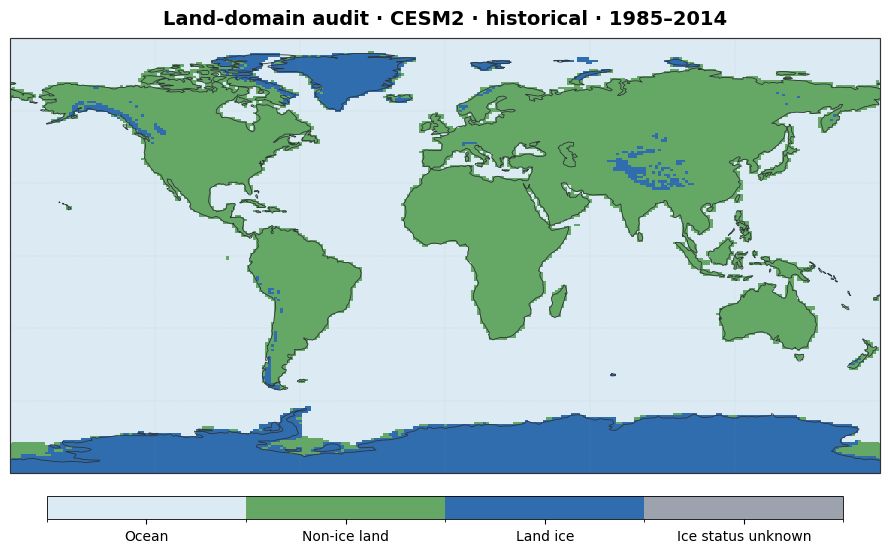

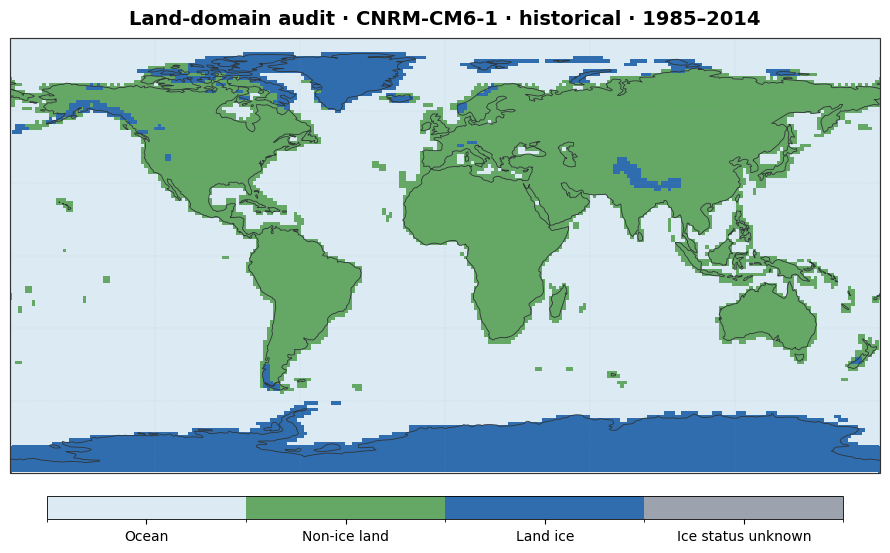

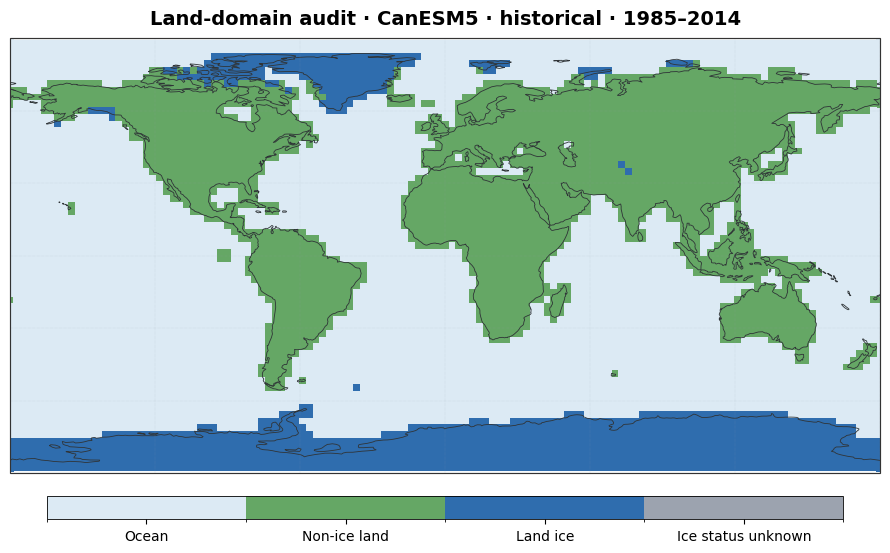

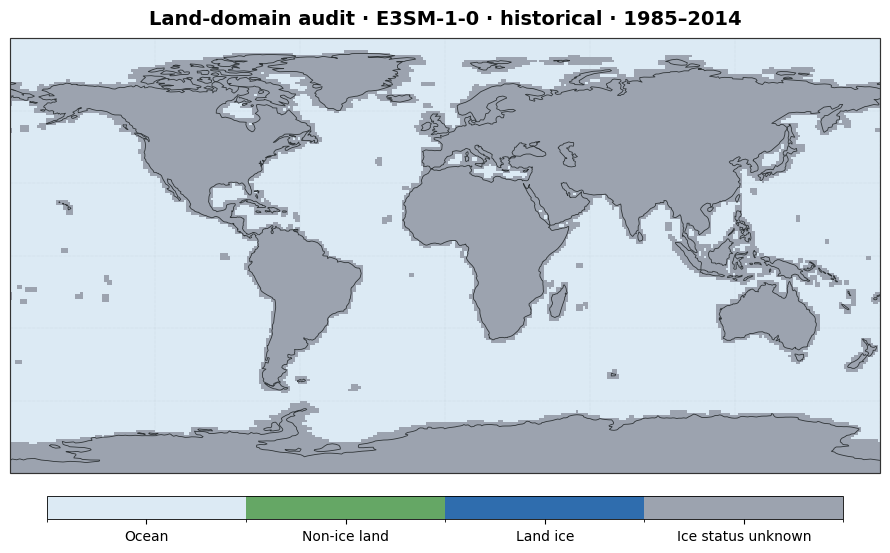

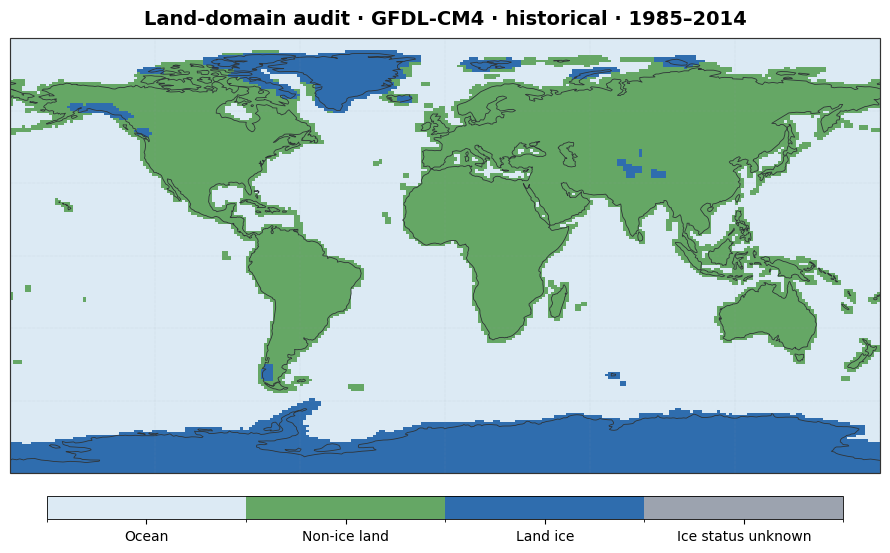

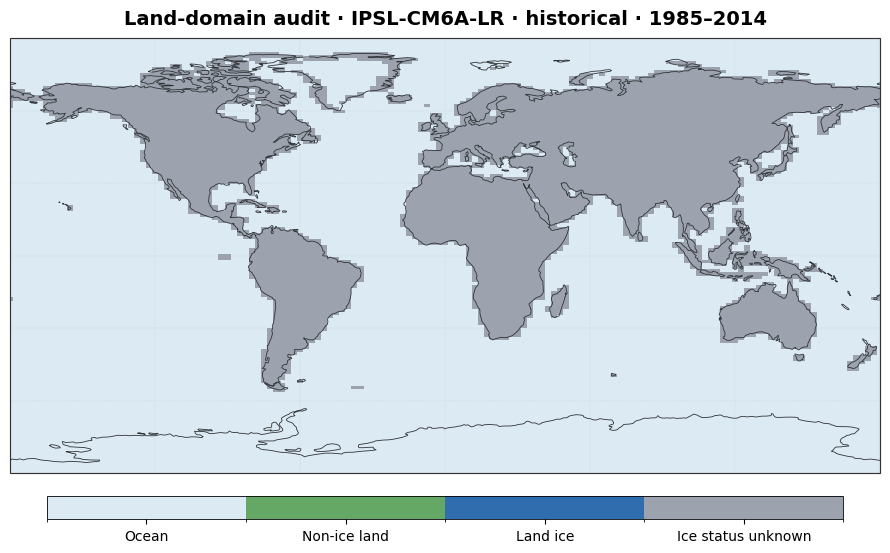

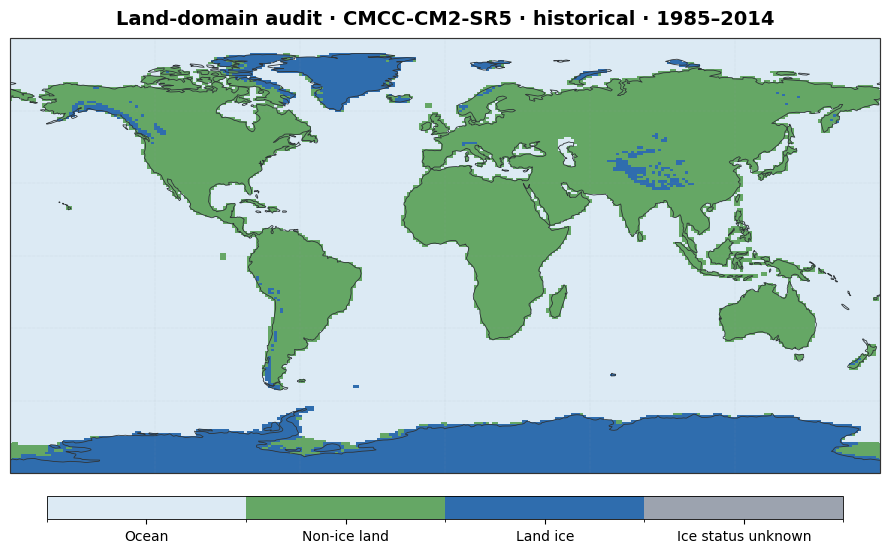

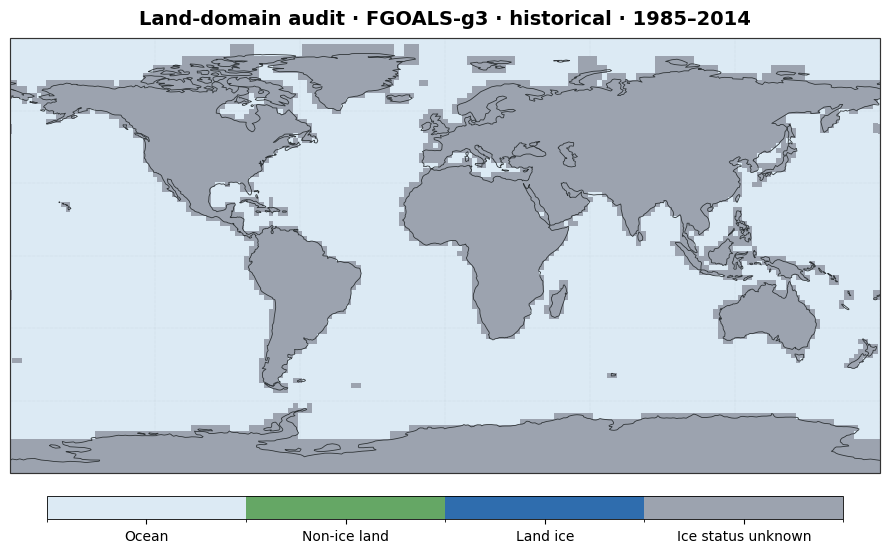

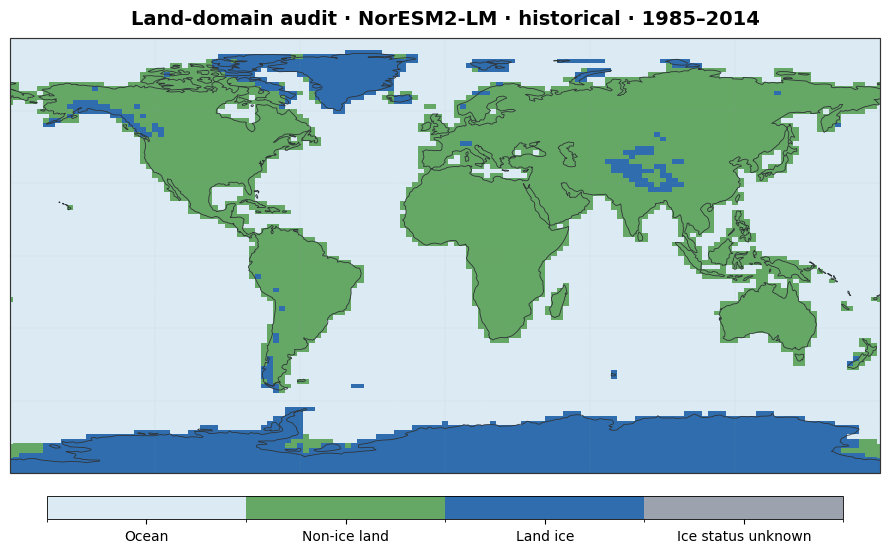

In [21]:
QC = pd.DataFrame([run['qc'] for run in LAND_RUNS])
display(QC)

class_colors = ['#DCEAF4', '#65A765', '#2F6DAE', '#9CA3AF']
class_cmap = ListedColormap(class_colors)
class_norm = BoundaryNorm(np.arange(-0.5, 4.5, 1.0), class_cmap.N)
projection = ccrs.PlateCarree()

for run in LAND_RUNS:
    data = run['land_climatology']['surface_class_code']
    fig, ax = plt.subplots(
        figsize=(11.8, 5.4), subplot_kw={'projection': projection}, constrained_layout=True
    )
    mesh = ax.pcolormesh(
        data['lon'], data['lat'], data, transform=ccrs.PlateCarree(),
        shading='auto', cmap=class_cmap, norm=class_norm, rasterized=True,
    )
    ax.set_global()
    ax.set_facecolor('#F7FAFC')
    ax.coastlines(resolution='110m', linewidth=0.6, color='#2F3437')
    ax.gridlines(linewidth=0.35, color='#9CA3AF', alpha=0.45, linestyle=':')
    ax.spines['geo'].set_edgecolor('#333333')
    ax.spines['geo'].set_linewidth(0.85)
    ax.set_title(
        f"Land-domain audit · {run['model']} · {run['experiment']} · "
        f"{START_YEAR}–{END_YEAR}",
        fontsize=14, fontweight='semibold', pad=10,
    )
    colorbar = fig.colorbar(
        mesh, ax=ax, orientation='horizontal', shrink=0.68, pad=0.045,
        aspect=34, ticks=[0, 1, 2, 3],
    )
    colorbar.ax.set_xticklabels(['Ocean', 'Non-ice land', 'Land ice', 'Ice status unknown'])
    colorbar.outline.set_linewidth(0.6)
    figure_path = run['output_dir'] / f'land_domain_map_{START_YEAR}_{END_YEAR}.png'
    fig.savefig(figure_path, dpi=220, bbox_inches='tight')
    run['domain_figure_path'] = figure_path
    plt.show()

## 5. Outputs and handoff / 输出与后续交接

S2 produces one reusable terrestrial dataset per S1 run. The next notebook may select all land or a surface-class subset and then construct variable pairs. The choice of area weight must remain explicit: `land_area`, `non_ice_land_area`, or `land_ice_area`.

**中文说明：** 每个S1 run都会得到陆地年度NetCDF、陆地气候态NetCDF、只含陆地行的气候态Parquet、只含陆地行的grid-year Parquet、域审计CSV和处理签名。S3可以根据`surface_class`选择全部陆地、非冰陆地或陆地冰，再生成变量对子；同时必须显式选择`land_area`、`non_ice_land_area`或`land_ice_area`作为相应分析域的权重。S2本身不替后续分析做这一选择。

In [22]:
OUTPUT_MANIFEST = []
for run in LAND_RUNS:
    paths = [*run['output_paths'], run['domain_figure_path']]
    for path in paths:
        OUTPUT_MANIFEST.append({
            'model': run['model'],
            'experiment': run['experiment'],
            'member': run['member'],
            'grid': run['grid'],
            'product': path.name,
            'size_MB': path.stat().st_size / 1e6,
            'path': str(path),
        })
OUTPUT_MANIFEST = pd.DataFrame(OUTPUT_MANIFEST)
display(OUTPUT_MANIFEST.round({'size_MB': 3}))


,model,experiment,member,grid,product,size_MB,path
0,CESM2,historical,r1i1p1f1,gn,land_annual_1985_2014.nc,268.582,/Volumes/mimi-T9/CMIP6/CESM2/historical/r1i1p1...
1,CESM2,historical,r1i1p1f1,gn,land_climatology_1985_2014.nc,12.004,/Volumes/mimi-T9/CMIP6/CESM2/historical/r1i1p1...
2,CESM2,historical,r1i1p1f1,gn,land_climatology_1985_2014.parquet,3.860,/Volumes/mimi-T9/CMIP6/CESM2/historical/r1i1p1...
3,CESM2,historical,r1i1p1f1,gn,land_grid_year_1985_2014.parquet,89.777,/Volumes/mimi-T9/CMIP6/CESM2/historical/r1i1p1...
4,CESM2,historical,r1i1p1f1,gn,land_domain_audit_1985_2014.csv,0.001,/Volumes/mimi-T9/CMIP6/CESM2/historical/r1i1p1...
...,...,...,...,...,...,...,...
58,NorESM2-LM,historical,r1i1p1f1,gn,land_climatology_1985_2014.parquet,0.867,/Volumes/mimi-T9/CMIP6/NorESM2-LM/historical/r...
59,NorESM2-LM,historical,r1i1p1f1,gn,land_grid_year_1985_2014.parquet,22.469,/Volumes/mimi-T9/CMIP6/NorESM2-LM/historical/r...
60,NorESM2-LM,historical,r1i1p1f1,gn,land_domain_audit_1985_2014.csv,0.001,/Volumes/mimi-T9/CMIP6/NorESM2-LM/historical/r...
61,NorESM2-LM,historical,r1i1p1f1,gn,land_processing_1985_2014.json,0.001,/Volumes/mimi-T9/CMIP6/NorESM2-LM/historical/r...
